In [4]:
#importar las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import seaborn as sns
import plotly.graph_objects as go
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer, Binarizer, RobustScaler, label_binarize
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, PowerTransformer
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.tree import DecisionTreeClassifier, export_text, DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

In [6]:
seed=12345
file_path = 'C:/Users/user/OneDrive - Universidad Complutense de Madrid (UCM)/Documentos/Titulo Propio/Machine Learning/Redes Neuronales/Python/Datasets/compress.csv' 
df = pd.read_csv(file_path)
#print(df.head())
#La variable de interés es strength, continua
print(f'\n Instancias: {df.shape[0]}; Variables: {df.shape[1]}')


 Instancias: 1030; Variables: 9


In [8]:
#renombramos variables para usarlas más cómodamente
nuevos_nombres = ['cement', 'blast','ash','water','plasticizer','coarse','fine','day','strength']

# Asignar nuevos nombres a las columnas
df.columns = nuevos_nombres

In [10]:
# hay valores perdidos?
df.isna().sum()

cement         0
blast          0
ash            0
water          0
plasticizer    0
coarse         0
fine           0
day            0
strength       0
dtype: int64

Preparamos la base de datos para la aplicación de redes neuronales:

    - Estandarizar/normalizar variables continuas
    - Convertir a dummies las variables categóricas
    - Evitar missing

In [12]:
# organiza las variables según su naturaleza
#hacer una lista con las variables input numericas
num_cols = ['cement', 'blast','ash','water','plasticizer','coarse','fine','day','strength']
#hacer una lista con las variables input categóricas: no hay

In [47]:
# Tuneo y evaluación predictiva del modelo para variable dependiente continua
# El grupo de variables predictoras se define y se fija
X = df[['cement','blast','water']]
y = df['strength']

# 1. Dividir los datos en entrenamiento y test (20% de los datos para test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

#2. No hay variables categóricas, no hay missing, estandarizo las continuas.
scaler= StandardScaler()
X_train=scaler.fit_transform(X_train) #busco la media y desviación típica en train, después transformo train
X_test=scaler.transform(X_test) #con la media y desviación típica que calculé en train, transformo test


red = MLPRegressor(random_state=seed,max_iter=800)
#definimos los parámetros que queremos tunear
params = {
    'hidden_layer_sizes': [5,7,9],
    'activation': ['tanh','relu'],
    'alpha': [0.001,0.0001]
}
scoring_metrics = ['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
# cv = crossvalidation con n folds con todas las combinaciones de parámetros
grid_search = GridSearchCV(estimator=red, 
                           param_grid=params, 
                           cv=4, scoring = scoring_metrics, refit='neg_mean_squared_error')

#ajusta en entrenamiento con todas las combinaciones
grid_search.fit(X_train, y_train)


C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer

GridSearchCV(cv=4, estimator=MLPRegressor(max_iter=800, random_state=12345),
             param_grid={'activation': ['tanh', 'relu'],
                         'alpha': [0.001, 0.0001],
                         'hidden_layer_sizes': [5, 7, 9]},
             refit='neg_mean_squared_error',
             scoring=['neg_mean_squared_error', 'neg_mean_absolute_error',
                      'r2'])

In [22]:
# Obtener resultados del grid search
results = pd.DataFrame(grid_search.cv_results_)
# Mostrar resultados
print("Resultados de Grid Search:")
print(results[['params','mean_test_neg_mean_absolute_error','mean_test_r2']])
#print(results) #para ver todos los atributos obtenidos y entender cómo usarlos

# Obtener el mejor modelo (en cuanto a optimización del criterio)
best_model = grid_search.best_estimator_
print(grid_search.best_estimator_)

Resultados de Grid Search:
                                               params  \
0   {'activation': 'tanh', 'alpha': 0.001, 'hidden...   
1   {'activation': 'tanh', 'alpha': 0.001, 'hidden...   
2   {'activation': 'tanh', 'alpha': 0.001, 'hidden...   
3   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...   
4   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...   
5   {'activation': 'tanh', 'alpha': 0.0001, 'hidde...   
6   {'activation': 'relu', 'alpha': 0.001, 'hidden...   
7   {'activation': 'relu', 'alpha': 0.001, 'hidden...   
8   {'activation': 'relu', 'alpha': 0.001, 'hidden...   
9   {'activation': 'relu', 'alpha': 0.0001, 'hidde...   
10  {'activation': 'relu', 'alpha': 0.0001, 'hidde...   
11  {'activation': 'relu', 'alpha': 0.0001, 'hidde...   

    mean_test_neg_mean_absolute_error  mean_test_r2  
0                          -22.890126     -1.853180  
1                          -19.133715     -1.104533  
2                          -17.851428     -0.861574  
3              

- params: Una lista de diccionarios que contiene los valores de los hiperparámetros para cada combinación evaluada.
- mean_test_score: Una matriz que contiene las puntuaciones promedio de prueba para cada combinación de hiperparámetros.
- std_test_score: Una matriz que contiene las desviaciones estándar de las puntuaciones de prueba para cada combinación de hiperparámetros.

Otros detalles como el tiempo de ajuste ('mean_fit_time'), tiempo de puntuación ('mean_score_time'), etc.

## Métricas de regresión
- neg_mean_squared_error: Error cuadrático medio negativo. Se utiliza comúnmente en problemas de regresión.
- neg_mean_absolute_error: Error absoluto medio negativo.
- r2: R^2 (Coeficiente de Determinación) mide la proporción de la variabilidad en la variable dependiente que es predecible a partir de las variables independientes.

Algunas métricas como el error cuadrático medio (neg_mean_squared_error) son más efectivas cuando son más bajas, mientras que otras como el coeficiente de determinación (r2) son más efectivas cuando son más altas. Al utilizar el parámetro scoring, ten en cuenta el sentido de la métrica y si deseas maximizarla o minimizarla al especificar greater_is_better


## OJO
`MLPRegressor` y otros modelos de sklearn reportan el MSE en negativo (neg_mean_squared_error) porque scikit-learn necesita que las métricas se maximicen. El MSE real es simplemente el valor absoluto. No implica que el error sea negativo, es solo una convención de scoring.

Tenemos que decidir qué redes candidatas nos quedamos: por ejemplo, las que tengan mejor MSE (lo más bajo posible). Como MLP calcula esta métrica en negativo, en realidad tendremos que fijarnos en el valor más alto

In [50]:
import pandas as pd

# Supongamos que tienes un DataFrame df con la columna mean_test_neg_mean_absolute_error
# ordenamos así porque está en negativo!! el MSE en general cuanto más bajo, mejor. En este caso, tenemos que aatender al valor absoluto
results = results.sort_values(by='mean_test_neg_mean_absolute_error', ascending=False)  # de mayor a menor
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_activation,param_alpha,param_hidden_layer_sizes,param_max_iter,params,split0_test_neg_mean_squared_error,...,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error,split0_test_r2,split1_test_r2,split2_test_r2,split3_test_r2,mean_test_r2,std_test_r2,rank_test_r2
9,0.917999,0.208726,0.002852,0.000737,relu,0.0001,5,500,"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",-185.837316,...,-11.259671,0.169199,1,0.309213,0.221602,0.311946,0.296222,0.284746,0.036937,1
6,0.983363,0.090957,0.003561,0.001015,relu,0.0010,5,500,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",-185.837384,...,-11.259678,0.169189,2,0.309213,0.221600,0.311945,0.296222,0.284745,0.036938,2
8,1.096983,0.264464,0.004221,0.000999,relu,0.0010,9,500,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",-191.070210,...,-11.601437,0.239977,3,0.289762,0.168276,0.240953,0.261687,0.240169,0.044977,3
11,0.856731,0.072218,0.002551,0.001812,relu,0.0001,9,500,"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",-191.070214,...,-11.601438,0.239978,4,0.289762,0.168275,0.240953,0.261687,0.240169,0.044977,4
10,0.791347,0.045026,0.003814,0.001170,relu,0.0001,7,500,"{'activation': 'relu', 'alpha': 0.0001, 'hidde...",-223.907021,...,-12.284123,0.271881,5,0.167702,-0.019164,0.096155,0.169729,0.103606,0.076825,6
7,0.990101,0.147918,0.002596,0.001835,relu,0.0010,7,500,"{'activation': 'relu', 'alpha': 0.001, 'hidden...",-223.907011,...,-12.284123,0.271880,6,0.167702,-0.019164,0.096156,0.169730,0.103606,0.076825,5
5,1.230175,0.163967,0.008974,0.009171,tanh,0.0001,9,500,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",-441.214336,...,-17.851424,1.075403,7,-0.640063,-1.215770,-0.746560,-0.843899,-0.861573,0.216831,7
2,1.041444,0.111016,0.004167,0.000980,tanh,0.0010,9,500,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",-441.214521,...,-17.851428,1.075403,8,-0.640064,-1.215771,-0.746561,-0.843900,-0.861574,0.216831,8
4,1.006413,0.127125,0.003021,0.000780,tanh,0.0001,7,500,"{'activation': 'tanh', 'alpha': 0.0001, 'hidde...",-505.888783,...,-19.133714,1.127773,9,-0.880468,-1.486752,-0.973385,-1.077526,-1.104533,0.231422,9
1,1.143250,0.073381,0.004498,0.000666,tanh,0.0010,7,500,"{'activation': 'tanh', 'alpha': 0.001, 'hidden...",-505.888895,...,-19.133715,1.127773,10,-0.880469,-1.486752,-0.973385,-1.077527,-1.104533,0.231422,10


In [52]:
# Escogemos la parametrizaciones mejores candidatas: 0, 1, 2
print("Parametrización 0:")
print(results.iloc[0].params)
print("Parametrización 1:")
print(results.iloc[1].params)
print("Parametrización 2:")
print(results.iloc[2].params)

Parametrización 0:
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': 5, 'max_iter': 500}
Parametrización 1:
{'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': 5, 'max_iter': 500}
Parametrización 2:
{'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': 9, 'max_iter': 500}


In [54]:
# se selecciona el modelo candidato, y se procede a analizar su robustez a lo largo de cross validation.
r2_0 = results[['split0_test_r2', 'split1_test_r2','split2_test_r2', 'split3_test_r2']].iloc[0]
r2_1 = results[['split0_test_r2', 'split1_test_r2','split2_test_r2', 'split3_test_r2']].iloc[1]
r2_2 =results[['split0_test_r2', 'split1_test_r2','split2_test_r2', 'split3_test_r2']].iloc[2]

# se selecciona el modelo candidato, y se procede a analizar su robustez a lo largo de cross validation.
# tomamos el valor absoluto porque está en negativo
mse_0 = results[['split0_test_neg_mean_squared_error', 'split1_test_neg_mean_squared_error','split2_test_neg_mean_squared_error', 'split3_test_r2']].iloc[0].abs()
mse_1 = results[['split0_test_neg_mean_squared_error', 'split1_test_neg_mean_squared_error','split2_test_neg_mean_squared_error', 'split3_test_r2']].iloc[1].abs()
mse_2 = results[['split0_test_neg_mean_squared_error', 'split1_test_neg_mean_squared_error','split2_test_neg_mean_squared_error', 'split3_test_r2']].iloc[2].abs()

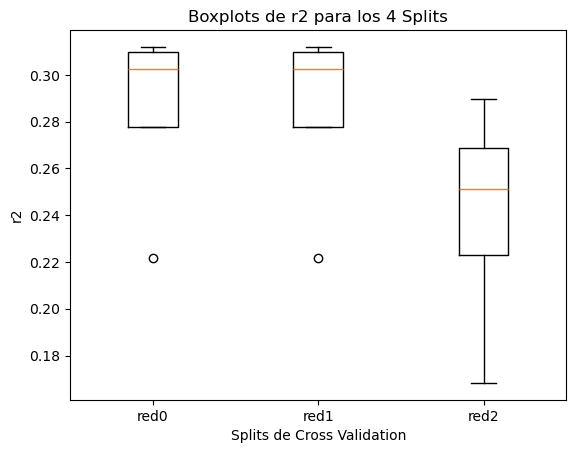

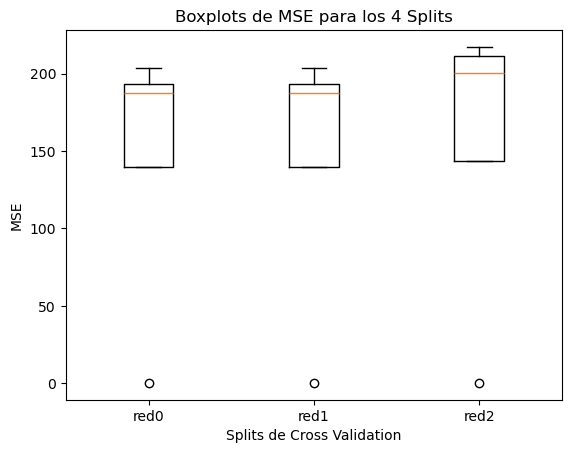

In [71]:
# Crear un boxplot para los cuatro valores de r2
plt.boxplot([r2_0.values,r2_1.values,r2_2.values], tick_labels = ['red0','red1','red2'])
plt.title('Boxplots de r2 para los 4 Splits')
plt.xlabel('Splits de Cross Validation')
plt.ylabel('r2')
plt.show()

# Crear un boxplot para los cuatro valores de MSE
plt.boxplot([mse_0.values,mse_1.values,mse_2.values], tick_labels = ['red0','red1','red2'])
plt.title('Boxplots de MSE para los 4 Splits')
plt.xlabel('Splits de Cross Validation')
plt.ylabel('MSE')
plt.show()


# boxplots con gran amplitud no son deseables, ya que se caracterizan por poca robustez de la solución

## Análisis
Parece que las redes 0 y 1 son las mejores opciones de las 3 analizadas (habría que analizar más!)
Vemos la parametrización

In [58]:
print(f'Arquitectura red 0: {results.iloc[0].params}')
print(f'Arquitectura red 1: {results.iloc[1].params}')

Arquitectura red 0: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': 5, 'max_iter': 500}
Arquitectura red 1: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': 5, 'max_iter': 500}


## Decisión?
Prácticamente igualdad de condiciones..sól hay diferencia en la regularización L2 dada por alpha:
- alpha grande: menor riesgo de overfitting, menor capacidad de aprendizaje, puede ser demasiado conservador
- alpha pequeño: mayor riesgo de overfitting, mayor capacidad de ajuste, puede memorizar ruido
A igualdad de condiciones, suele ser mejor optar por mayor regularización. Por lo que nos quedamos con la red 0. Como 5 está en un extremo de la parrilla, habría que probar con valores más bajos e intermedios, por ejemplo, con 3, 4, 5 y 6 nodos ocultos. Parece que la activación relu funciona bien..podríamos asumir que va a seguir siendo así, y limitarnos a tunear los nodos ocultos fijando activación y alpha...pero nada me garantiza que para una cantidad distinta de nodos esto se vaya a mantener.

Tengo que tomar una decisión dependiendo de mi intuición y del tiempo que tenga.. Por simplificar, doy por buena la arquitectura, y sólo tuneo los nodos ocultos

In [60]:
# Tuneo y evaluación predictiva del modelo para variable dependiente continua
# El grupo de variables predictoras se define y se fija
X = df[['cement','blast','water']]
y = df['strength']

# 1. Dividir los datos en entrenamiento y test (20% de los datos para test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

#2. No hay variables categóricas, no hay missing, estandarizo las continuas.
scaler= StandardScaler()
X_train=scaler.fit_transform(X_train) #busco la media y desviación típica en train, después transformo train
X_test=scaler.transform(X_test) #con la media y desviación típica que calculé en train, transformo test


red2 = MLPRegressor(random_state=seed,max_iter=800,activation='relu',alpha=0.001)
#definimos los parámetros que queremos tunear
params2 = {
    'hidden_layer_sizes': [3,4,5,6]
}
scoring_metrics = ['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']
# cv = crossvalidation con n folds con todas las combinaciones de parámetros
grid_search2 = GridSearchCV(estimator=red2, 
                           param_grid=params2, 
                           cv=4, scoring = scoring_metrics, refit='neg_mean_squared_error')

#ajusta en entrenamiento con todas las combinaciones
grid_search2.fit(X_train, y_train)

C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer

GridSearchCV(cv=4,
             estimator=MLPRegressor(alpha=0.001, max_iter=800,
                                    random_state=12345),
             param_grid={'hidden_layer_sizes': [3, 4, 5, 6]},
             refit='neg_mean_squared_error',
             scoring=['neg_mean_squared_error', 'neg_mean_absolute_error',
                      'r2'])

## CUIDADO
Todas las decisiones se están tomando sin convergencia...nada nos garantiza que se haya estabilizado la función de error

In [65]:
# Obtener resultados del grid search
results2 = pd.DataFrame(grid_search2.cv_results_)

# Supongamos que tienes un DataFrame df con la columna mean_test_neg_mean_absolute_error
# ordenamos así porque está en negativo!! el MSE en general cuanto más bajo, mejor. En este caso, tenemos que aatender al valor absoluto
results2 = results2.sort_values(by='mean_test_neg_mean_absolute_error', ascending=False)  # de mayor a menor
results2

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_hidden_layer_sizes,params,split0_test_neg_mean_squared_error,split1_test_neg_mean_squared_error,split2_test_neg_mean_squared_error,split3_test_neg_mean_squared_error,...,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error,split0_test_r2,split1_test_r2,split2_test_r2,split3_test_r2,mean_test_r2,std_test_r2,rank_test_r2
2,1.538091,0.147165,0.004075,0.000966,5,{'hidden_layer_sizes': 5},-160.931234,-165.369660,-157.797956,-185.212192,...,-10.413924,0.349680,1,0.401793,0.366694,0.427209,0.326565,0.380565,0.037864,2
3,1.651164,0.168235,0.004119,0.001350,6,{'hidden_layer_sizes': 6},-158.148041,-161.589198,-156.873830,-191.896188,...,-10.458346,0.411227,2,0.412139,0.381171,0.430563,0.302261,0.381534,0.049053,1
1,1.842499,0.092427,0.005165,0.002432,4,{'hidden_layer_sizes': 4},-188.322871,-174.463209,-181.925839,-187.378597,...,-10.874097,0.418416,3,0.299974,0.331868,0.339627,0.318687,0.322539,0.015025,3
0,1.607884,0.163581,0.002974,0.001061,3,{'hidden_layer_sizes': 3},-523.294631,-860.898034,-587.325213,-639.316712,...,-20.372230,1.919906,4,-0.945169,-2.296931,-1.131934,-1.324569,-1.424651,0.521170,4


In [69]:
# Como solo son 4, los miro todos

# se selecciona el modelo candidato, y se procede a analizar su robustez a lo largo de cross validation.
r2_0_2 = results2[['split0_test_r2', 'split1_test_r2','split2_test_r2', 'split3_test_r2']].iloc[0]
r2_1_2 = results2[['split0_test_r2', 'split1_test_r2','split2_test_r2', 'split3_test_r2']].iloc[1]
r2_2_2 =results2[['split0_test_r2', 'split1_test_r2','split2_test_r2', 'split3_test_r2']].iloc[2]
r2_3_2 =results2[['split0_test_r2', 'split1_test_r2','split2_test_r2', 'split3_test_r2']].iloc[3]

# se selecciona el modelo candidato, y se procede a analizar su robustez a lo largo de cross validation.
# tomamos el valor absoluto porque está en negativo
mse_0_2 = results2[['split0_test_neg_mean_squared_error', 'split1_test_neg_mean_squared_error','split2_test_neg_mean_squared_error', 'split3_test_r2']].iloc[0].abs()
mse_1_2 = results2[['split0_test_neg_mean_squared_error', 'split1_test_neg_mean_squared_error','split2_test_neg_mean_squared_error', 'split3_test_r2']].iloc[1].abs()
mse_2_2 = results2[['split0_test_neg_mean_squared_error', 'split1_test_neg_mean_squared_error','split2_test_neg_mean_squared_error', 'split3_test_r2']].iloc[2].abs()
mse_3_2 = results2[['split0_test_neg_mean_squared_error', 'split1_test_neg_mean_squared_error','split2_test_neg_mean_squared_error', 'split3_test_r2']].iloc[3].abs()

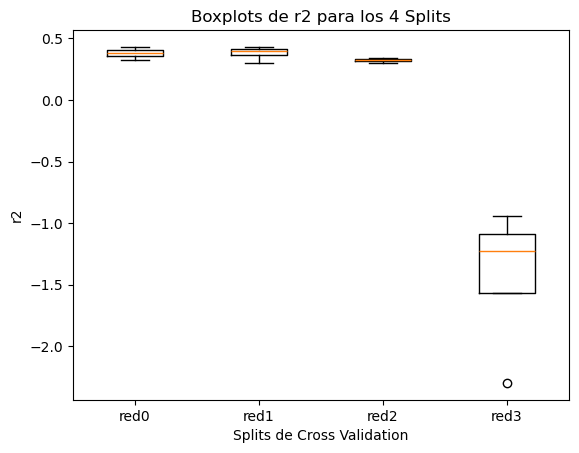

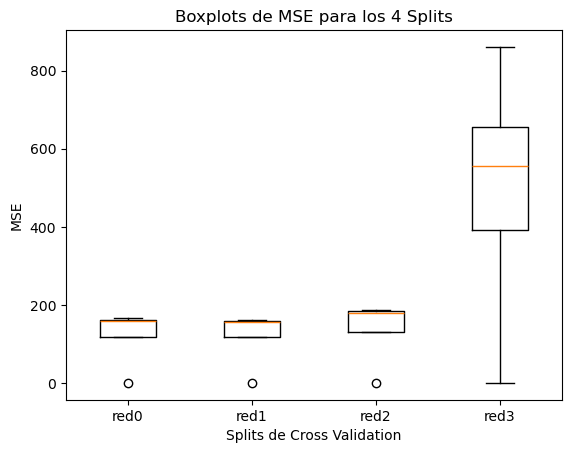

In [76]:
# Crear un boxplot para los cuatro valores de r2
plt.boxplot([r2_0_2.values,r2_1_2.values,r2_2_2.values,r2_3_2.values], tick_labels = ['red0','red1','red2','red3'])
plt.title('Boxplots de r2 para los 4 Splits')
plt.xlabel('Splits de Cross Validation')
plt.ylabel('r2')
plt.show()

# Crear un boxplot para los cuatro valores de MSE
plt.boxplot([mse_0_2.values,mse_1_2.values,mse_2_2.values,mse_3_2.values], tick_labels = ['red0','red1','red2','red3'])
plt.title('Boxplots de MSE para los 4 Splits')
plt.xlabel('Splits de Cross Validation')
plt.ylabel('MSE')
plt.show()


# Nótese en la solución que boxplots con gran amplitud no son deseables, ya que se caracterizan por poca robustez de la solución

## Decisión
En vista de los resultados, descarto la red 3, vamos a ver los parámetros de las otras para tratar de discernir en función de la complejidad

In [79]:
print(f'Arquitectura red 0: {results2.iloc[0].params}')
print(f'Arquitectura red 1: {results2.iloc[1].params}')
print(f'Arquitectura red 2: {results2.iloc[2].params}')

Arquitectura red 0: {'hidden_layer_sizes': 5}
Arquitectura red 1: {'hidden_layer_sizes': 6}
Arquitectura red 2: {'hidden_layer_sizes': 4}


## Entonces...

La red 2 funciona un pelín peor pero es más sencilla, las otras dos tienen una calidad muy similar (elegiría la de 5)
Si me interesa la simplicidad, me quedo con la red 2.
Si me compensa esa pequeña ganancia en calidad, me quedo con la red 0.
Supongamos que me quedo con la red 0. Antes de ponerla en 

# Paso final
Una vez que hemos escogido nuestro modelo candidato ganador, después de haber hecho todas las pruebas de CV que garantizan estabilidad y haber expuesto los argumentos que sustentan por qué es mi modelo candidato, tengo que volver a hacer la partición tr/ts, entrenar el modelo replicando exactamente el flujo de trabajo (incluyendo transformaciones y selección de variables), y volver a entrenarlo. Los parámetros obtenidos en entrenamiento serán los que se lleven a la producción. La calidad evaluada para esos parámetros en la parte de test, será la calidad final de mi modelo.

**IMPORTANTE** replicar el proceso de preparación hasta llegar a la arquitectura de la red

In [83]:
from sklearn.metrics import r2_score


# El grupo de variables predictoras se define y se fija
X = df[['cement','blast','water']]
y = df['strength']

# 1. Dividir los datos en entrenamiento y test (20% de los datos para test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

#2. No hay variables categóricas, no hay missing, estandarizo las continuas.
scaler= StandardScaler()
X_train=scaler.fit_transform(X_train) #busco la media y desviación típica en train, después transformo train
X_test=scaler.transform(X_test) #con la media y desviación típica que calculé en train, transformo test


candidata =MLPRegressor(**results.iloc[0].params, random_state=seed)
# Ajustar el mejor modelo con todo el conjunto de entrenamiento
candidata.fit(X_train, y_train)

# Predicciones en conjunto de entrenamiento y prueba
y_train_pred = candidata.predict(X_train)
y_test_pred = candidata.predict(X_test)


errores = y_train - y_train_pred
# Calcular diferentes medidas de bondad de ajuste
mae = mean_absolute_error(y_test, y_test_pred)
mae_tr = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_test, y_test_pred)
mse_tr = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
rmse_tr = np.sqrt(mse_tr)
r2_tr = r2_score(y_train, y_train_pred)
r2_ts = r2_score(y_test, y_test_pred)

# Imprimir las métricas
print(f'MAE (Error Absoluto Medio test): {mae:.2f}')
print(f'MSE (Error Cuadrático Medio test): {mse:.2f}')
print(f'RMSE (Raíz del Error Cuadrático Medio test): {rmse:.2f}')
print(f'R² test: {r2_ts:.2f}')

print(f'MAE (Error Absoluto Medio tr): {mae_tr:.2f}')
print(f'MSE (Error Cuadrático Medio tr): {mse_tr:.2f}')
print(f'RMSE (Raíz del Error Cuadrático Medio tr): {rmse_tr:.2f}')
print(f'R² tr: {r2_tr:.2f}')

MAE (Error Absoluto Medio test): 11.39
MSE (Error Cuadrático Medio test): 195.14
RMSE (Raíz del Error Cuadrático Medio test): 13.97
R² test: 0.35
MAE (Error Absoluto Medio tr): 10.50
MSE (Error Cuadrático Medio tr): 170.36
RMSE (Raíz del Error Cuadrático Medio tr): 13.05
R² tr: 0.37


C:\Users\user\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
